In [1]:
# 0. System Mapping and Drive Mount
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Import Core Analytics and Scaling Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import os

# Force modern visualization styles
sns.set_theme(style="whitegrid")

### 1. Extracted Data Pipeline Loading & Exploratory Data Analysis (EDA)

Loading extracted landmarks from final_extracted_landmarks_full_MERGED.csv...
Success! Found DataFrame with shape: (31082, 64)


/tmp/ipython-input-731034000.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


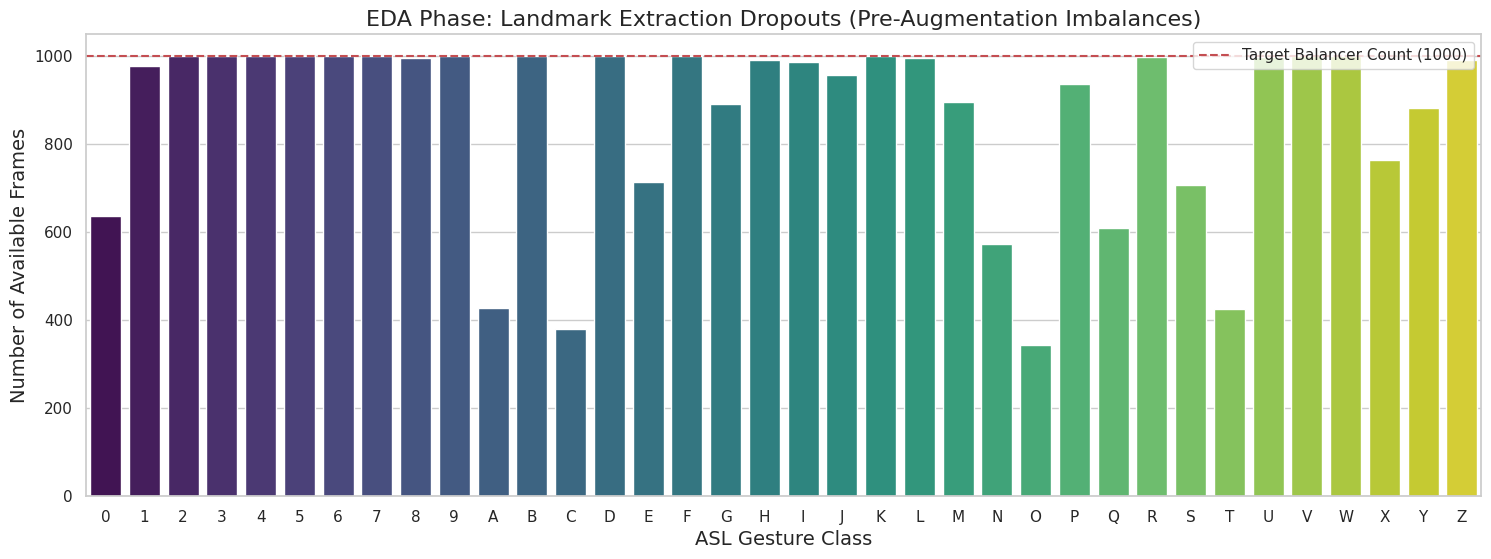


--- Imbalance Analysis ---
Maximum class count observed: 1000
Minimum class count observed: 343
Target Frame Augmentation Deficit (Max - Min): 657 frames


In [4]:
# Load the dataset. 
# Update to final_extracted_landmarks_full.csv when moving past the demo file!
CSV_FILE_PATH = '../data/final_extracted_landmarks_full_MERGED.csv'

print(f"Loading extracted landmarks from {os.path.basename(CSV_FILE_PATH)}...")
try:
    df = pd.read_csv(CSV_FILE_PATH)
    print(f"Success! Found DataFrame with shape: {df.shape}")
except FileNotFoundError:
    print("\n[!] ERROR: Dataset not found. Please verify the CSV path exists in your Google Drive.")

if 'df' in locals():
    # Exploratory Data Analysis: Visualizing Class Imbalances
    plt.figure(figsize=(18, 6))
    class_counts = df['class_label'].value_counts().sort_index()

    sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
    plt.title("EDA Phase: Landmark Extraction Dropouts (Pre-Augmentation Imbalances)", fontsize=16)
    plt.ylabel("Number of Available Frames", fontsize=14)
    plt.xlabel("ASL Gesture Class", fontsize=14)
    plt.axhline(class_counts.max(), color='r', linestyle='--', label=f'Target Balancer Count ({class_counts.max()})')
    plt.legend()
    plt.show()

    print("\n--- Imbalance Analysis ---")
    print(f"Maximum class count observed: {class_counts.max()}")
    print(f"Minimum class count observed: {class_counts.min()}")
    print(f"Target Frame Augmentation Deficit (Max - Min): {class_counts.max() - class_counts.min()} frames")

### 2. Dataset Cleansing & Wrist-Centric Spatial Normalization

In [5]:
# Check and explicitly purge absolute corruption rows
starting_len = len(df)
df.dropna(inplace=True)
print(f"Cleansing Nulls: Removed {starting_len - len(df)} corrupted rows.")

# Separate features from descriptive labels
X_raw = df.drop('class_label', axis=1).values
y_labels = df['class_label'].values

# Wrist-Centric Normalization System
# First 3 columns (x0, y0, z0) constitute the origin landmark
print("\nInitiating Wrist-Centric Normalization...")
X_normalized = np.zeros_like(X_raw)

for i in tqdm(range(len(X_raw)), desc="Anchoring Spatial Data"):
    # Capture Wrist base anchors
    wrist_x, wrist_y, wrist_z = X_raw[i, 0], X_raw[i, 1], X_raw[i, 2]
    
    # Subtract the wrist's absolute position from ALL 21 landmarks
    for j in range(0, 63, 3):
        X_normalized[i, j]   = X_raw[i, j]   - wrist_x  # Normalize x
        X_normalized[i, j+1] = X_raw[i, j+1] - wrist_y  # Normalize y
        X_normalized[i, j+2] = X_raw[i, j+2] - wrist_z  # Normalize z
        
print("\nNormalization Validation: Passed! Translation invariance established. Wrist is centered dynamically at (0, 0, 0).")

Cleansing Nulls: Removed 0 corrupted rows.

Initiating Wrist-Centric Normalization...


Anchoring Spatial Data:   0%|          | 0/31082 [00:00<?, ?it/s]


Normalization Validation: Passed! Translation invariance established. Wrist is centered dynamically at (0, 0, 0).


### 3. Data Simulation & Numeric Augmentation (Resolving Imbalances)

In [6]:
def augment_to_target_variance(X_class, y_class, target_count, noise_factor=0.012):
    """
    Dynamically loops and generates safe synthetic coordinate sequences using Gaussian Noise.
    """
    current_count = len(X_class)
    deficit = target_count - current_count
    
    if deficit <= 0:
        return X_class, y_class  # No simulation needed
        
    # Select uniformly random frames from this class to serve as a base geometry
    indices_to_augment = np.random.choice(current_count, deficit, replace=True)
    base_samples = X_class[indices_to_augment]
    
    # Apply 3D coordinate standard normal fluctuation
    noise = np.random.normal(loc=0.0, scale=noise_factor, size=base_samples.shape)
    synthetic_samples = base_samples + noise
    
    # Strict Retention: Force the wrist at precisely (0,0,0) so the augmented frames don't break normalization
    synthetic_samples[:, 0:3] = 0.0 
    
    synthetic_labels = np.full(deficit, y_class[0])
    return np.vstack([X_class, synthetic_samples]), np.concatenate([y_class, synthetic_labels])

print("Analyzing maximal bound capacities...")
unique_classes, counts = np.unique(y_labels, return_counts=True)
target_max_count = np.max(counts)

X_balanced = []
y_balanced = []

for cls in tqdm(unique_classes, desc="Injecting Synthetic Augmentations"):
    class_mask = (y_labels == cls)
    X_cls_subset = X_normalized[class_mask]
    y_cls_subset = y_labels[class_mask]
    
    # Route through algorithm
    X_aug, y_aug = augment_to_target_variance(X_cls_subset, y_cls_subset, target_max_count)
    
    X_balanced.append(X_aug)
    y_balanced.append(y_aug)

# Merge master tensor stack
X_final = np.vstack(X_balanced)
y_final = np.concatenate(y_balanced)

print(f"\n--- Post-Augmentation Imbalance Diagnostics ---")
print(f"Original Extracted Feature Tensors: {X_normalized.shape}")
print(f"Augmented Balanced Tensors Output:  {X_final.shape}")

Analyzing maximal bound capacities...


Injecting Synthetic Augmentations:   0%|          | 0/36 [00:00<?, ?it/s]


--- Post-Augmentation Imbalance Diagnostics ---
Original Extracted Feature Tensors: (31082, 63)
Augmented Balanced Tensors Output:  (36000, 63)


### 4. Post-Augmentation EDA Feedback Loop

/tmp/ipython-input-843752476.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=balanced_counts.index, y=balanced_counts.values, palette='mako')


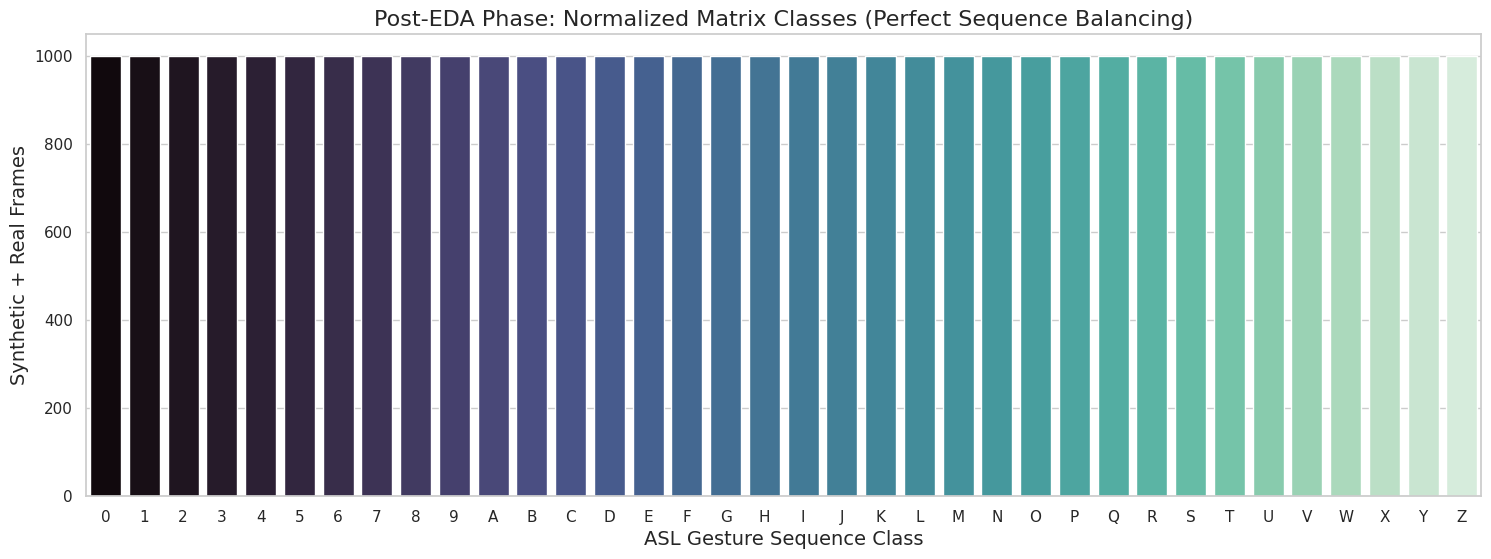

SUCCESS! Model is mathematical sound against frequency biases.


In [7]:
plt.figure(figsize=(18, 6))
balanced_counts = pd.Series(y_final).value_counts().sort_index()

sns.barplot(x=balanced_counts.index, y=balanced_counts.values, palette='mako')
plt.title("Post-EDA Phase: Normalized Matrix Classes (Perfect Sequence Balancing)", fontsize=16)
plt.ylabel("Synthetic + Real Frames", fontsize=14)
plt.xlabel("ASL Gesture Sequence Class", fontsize=14)
plt.show()

assert len(set(balanced_counts.values)) == 1, "[FATAL ERROR] Dataset imbalance still detected!"
print("SUCCESS! Model is mathematical sound against frequency biases.")

### 5. Finalize Outputs for Neural Network Shape Requirements `(Samples, Timesteps, Dimensions)`

In [8]:
# String Labels to Ordinal Integers 
print("Label Encoding 'Class' -> Mapping...")
encoder = LabelEncoder()
y_numeric = encoder.fit_transform(y_final)

# Multi-Dimensional Tensor Restructuring
# Convert flattened (N, 63) arrays into 3D LSTM shapes (N, 21, 3)
print("\nMatrix Translation Mapping...")
try:
    X_3D_Tensor = X_final.reshape(-1, 21, 3)
    print(f"LSTM Optimized Extradimensional Array Formatted At: {X_3D_Tensor.shape}")
except Exception as e:
    print(f"[!] Reshape Dimension Error: {e}")

# Committing sequence saves back to original local storage volume
OUTPUT_DIR = '../data/'
X_OUT_PATH = os.path.join(OUTPUT_DIR, 'X_balanced_features.npy')
Y_OUT_PATH = os.path.join(OUTPUT_DIR, 'y_balanced_labels.npy')

print("\nExecuting Secure System File Uploads to Drive...")
np.save(X_OUT_PATH, X_3D_Tensor)
np.save(Y_OUT_PATH, y_numeric)
np.save(os.path.join(OUTPUT_DIR, 'classes_mapping.npy'), encoder.classes_)

print("Your datasets are successfully formatted for a CNN/LSTM interface.")
print(f"Tensor Features >>> {X_OUT_PATH}")
print(f"Numeric Labels  >>> {Y_OUT_PATH}")
print(f"Original Values >>> classes_mapping.npy")


Label Encoding 'Class' -> Mapping...

Matrix Translation Mapping...
LSTM Optimized Extradimensional Array Formatted At: (36000, 21, 3)

Executing Secure System File Uploads to Drive...
Your datasets are successfully formatted for a CNN/LSTM interface.
Tensor Features >>> ../data/X_balanced_features.npy
Numeric Labels  >>> ../data/y_balanced_labels.npy
Original Values >>> classes_mapping.npy
